In [32]:
# データ生成
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from joblib import Parallel, delayed

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 8                   # アンサンブルメンバー数 (過酷な環境テスト)
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 5
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)
R_mat = np.eye(N) * 20

# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成
# =====================================================================
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 1.001

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)
y_o_data_full = true_states + noise

num_cycles = y_o_data_full.shape[0]

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


In [33]:
#共通関数（汎用化）

def get_experiment_matrices(obs_indices):
    p_obs = len(obs_indices)
    H_mat = np.zeros((p_obs, N))
    for k, j in enumerate(obs_indices):
        H_mat[k, j] = 1.0
    R_mat = np.eye(p_obs)
    return H_mat, R_mat

def get_localization_weights(sigma, obs_indices):
    p_obs = len(obs_indices)
    W_weights = np.zeros((N, p_obs))
    def L(d):
        if d < np.sqrt(10.0 / 3.0) * sigma * 2.0:
            return np.exp(- (d**2) / (2.0 * sigma**2))
        return 0.0
    
    for i in range(N):
        for k, j in enumerate(obs_indices):
            d = min(abs(i - j), N - abs(i - j))
            W_weights[i, k] = L(d)
    return W_weights

def run_LETKF_Adaptive_Moving_Agile(
    init_delta, 
    v_b_val, 
    move_interval, 
    move_step, 
    swath_size, 
    sigma, 
    H_mats, 
    W_weights_list, 
    obs_indices_history
):
    """
    LETKF適応インフレーションのコア実行関数
    """
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw = np.full(N, F)
    x_raw[min(19, N-1)] += 1.001
    X_a = M(x_raw[:, None] + init_noise, dt, steps_spin_up)
    
    delta_array = np.full(N, init_delta)
    v_b = np.full(N, v_b_val)
    
    record_rmse_global = np.zeros(num_cycles)
    record_rmse_land = np.zeros(num_cycles)
    record_rmse_ocean = np.zeros(num_cycles)
    record_delta_history = np.zeros((num_cycles, N))
    
    for t in range(num_cycles):
        # シフト量の計算
        shift = ((t // move_interval) * move_step) % N
        curr_obs_indices = obs_indices_history[shift]
        curr_unobs_indices = np.setdiff1d(np.arange(N), curr_obs_indices)
        obs_size = len(curr_obs_indices)
        
        H_mat = H_mats[shift]
        W_weights = W_weights_list[shift]
        y_o = np.asarray(y_o_data_full[t, curr_obs_indices]).ravel()
        R_diag = np.ones(obs_size)
        
        X_b = M(X_a, dt, sampling_interval)
        
        # 【修正点1】予測値が発散した場合、RMSEを無限大にして終了する
        if not np.all(np.isfinite(X_b)):
            record_rmse_global[:] = np.inf
            record_rmse_land[:] = np.inf
            record_rmse_ocean[:] = np.inf
            return record_rmse_global, record_rmse_land, record_rmse_ocean, record_delta_history
            
        x_b_mean = np.mean(X_b, axis=1)
        
        inflation_factor = np.sqrt(1.0 + delta_array) / np.sqrt(m - 1.0)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor[:, None]
        Y_b = H_mat @ Z_b
        innovation = np.asarray(y_o - (H_mat @ x_b_mean)).ravel()
        
        infl_at_obs = np.asarray(1.0 + delta_array[curr_obs_indices]).ravel()
        H_Pf_H_T_diag = np.asarray(np.sum(Y_b**2, axis=1) / infl_at_obs).ravel()
        
        X_a = np.zeros((N, m))
        delta_array_next = np.zeros(N)
        
        for i in range(N):
            w_i = W_weights[i, :]
            R_loc_inv_diag = np.diag(w_i / R_diag)
            
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag @ Y_b)
            
            # 【修正点2】固有値計算が失敗（特異行列など）した場合も無限大にして終了する
            try:
                D, C = np.linalg.eigh(P_a_tilde_inv)
            except np.linalg.LinAlgError:
                record_rmse_global[:] = np.inf
                record_rmse_land[:] = np.inf
                record_rmse_ocean[:] = np.inf
                return record_rmse_global, record_rmse_land, record_rmse_ocean, record_delta_history
                
            P_a_tilde = C @ np.diag(1.0 / D) @ C.T
            W_mat = C @ np.diag(1.0 / np.sqrt(D)) @ C.T
            w_vec = P_a_tilde @ Y_b.T @ R_loc_inv_diag @ innovation
            T_mat = w_vec[:, None] + np.sqrt(m - 1.0) * W_mat
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T_mat
            
            valid = H_Pf_H_T_diag > 1e-10
            if np.sum(w_i[valid]) > 1e-10:
                # 観測値の差分平方と、期待される分散の和を計算
                # E[d^2] = alpha * (HPH^T) + R
                # -> alpha * (HPH^T) = d^2 - R
                # -> alpha = Sum(w * (d^2 - R)) / Sum(w * HPH^T)

                numerator = np.sum(w_i[valid] * (innovation[valid]**2 - R_diag[valid]))
                denominator = np.sum(w_i[valid] * H_Pf_H_T_diag[valid])

                # ゼロ除算防止（分母が非常に小さい場合は調整なし、あるいは前ステップの維持）
                if denominator > 1e-10:
                    alpha_o_i = numerator / denominator
                else:
                    alpha_o_i = 1.0 # 補正なし
                    
                delta_o_i = alpha_o_i - 1.0
                
                
                alpha_b_i = 1.0 + delta_array[i]
                mole_v = w_i[valid] * ((alpha_b_i * H_Pf_H_T_diag[valid] + R_diag[valid]) / H_Pf_H_T_diag[valid])**2
                v_o_i = 2.0 * np.sum(mole_v) / (np.sum(w_i[valid])**2)
            else:
                delta_o_i, v_o_i = 0.0, 1e10
            
            k_gain = v_b[i] / (v_b[i] + v_o_i)
            delta_a = delta_array[i] + k_gain * (delta_o_i - delta_array[i])
            delta_array_next[i] = np.clip(delta_a, 0.0, 2.0)
            
        delta_array = delta_array_next.copy()
        record_delta_history[t, :] = delta_array
        
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse_global[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        record_rmse_land[t] = np.sqrt(np.mean((x_a_mean[curr_obs_indices] - true_states[t, curr_obs_indices])**2))
        record_rmse_ocean[t] = np.sqrt(np.mean((x_a_mean[curr_unobs_indices] - true_states[t, curr_unobs_indices])**2))
            
    return record_rmse_global, record_rmse_land, record_rmse_ocean, record_delta_history

## パラメータ設定

In [34]:
# =====================================================================
# 3. 実行パラメータ設定 
# =====================================================================

# --- 実験設定 (sigmaは後で探索して埋めます) ---
CONFIG = {
    "v_b": 0.040**2,       
    "move_interval": 1,  
    "move_step": 0,       
    "swath_size": 20
}


### 最適 $\sigma$ 探索

In [35]:
# =====================================================================
# 4. 最適Sigma探索と本番実行
# =====================================================================

sigma_list = np.arange(1.0, 5.0, 1.0)  # 探索するSigmaの候補
best_sigma = None
min_rmse = float('inf')

print(f"事前準備中 (H_mats, obs_hist の生成)...")
# H行列と観測インデックスはSigmaに依存しないため、最初に1回だけ生成
H_mats, obs_hist = [], []
for shift in range(N):
    idx = (np.arange(0, CONFIG["swath_size"]) + shift) % N
    obs_hist.append(idx)
    H, _ = get_experiment_matrices(idx) 
    H_mats.append(H)

# --- 1. 最適Sigmaの探索 ---
print(f"現在の動的条件(Interval={CONFIG['move_interval']}, Step={CONFIG['move_step']})における最適Sigmaを探索中...")
sigma_rmse_list = []

for s in sigma_list:
    # 現在の候補Sigmaで重み行列を生成
    W_list_temp = []
    for shift in range(N):
        W_list_temp.append(get_localization_weights(s, obs_hist[shift]))
    
    # 探索用実行 (適応インフレーション)
    rmse_G_temp, _, _, _ = run_LETKF_Adaptive_Moving_Agile(
        0.0, CONFIG["v_b"], CONFIG["move_interval"], CONFIG["move_step"], 
        CONFIG["swath_size"], s, H_mats, W_list_temp, obs_hist
    )
    
    # スピンアップ（最初の20%）を除外して平均RMSEを評価
    ex_c = int(num_cycles * 0.2)
    mean_rmse = np.mean(rmse_G_temp[ex_c:])
    sigma_rmse_list.append((s, mean_rmse))
    print(f"  Sigma = {s:.1f} -> Mean Global RMSE = {mean_rmse:.4f}")
    
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
        best_sigma = s

print(f"--> 最適Sigmaが {best_sigma:.1f} に決定されました (RMSE: {min_rmse:.4f})")
CONFIG["sigma"] = best_sigma

# --- 2. 本番実行 ---
print(f"\n動的LETKFを本番実行中... {CONFIG}")
start_time = time.time()

# 最適決定されたSigmaで最終的な重み行列を生成
W_list_final = []
for shift in range(N):
    W_list_final.append(get_localization_weights(CONFIG["sigma"], obs_hist[shift]))

rmse_G, rmse_L, rmse_O, delta_hist = run_LETKF_Adaptive_Moving_Agile(
    0.0, 
    CONFIG["v_b"], 
    CONFIG["move_interval"], 
    CONFIG["move_step"], 
    CONFIG["swath_size"], 
    CONFIG["sigma"],
    H_mats, 
    W_list_final, 
    obs_hist
)

print(f"実行完了 ({time.time() - start_time:.1f}秒)")

事前準備中 (H_mats, obs_hist の生成)...
現在の動的条件(Interval=1, Step=0)における最適Sigmaを探索中...
  Sigma = 1.0 -> Mean Global RMSE = 2.0175
  Sigma = 2.0 -> Mean Global RMSE = 1.9661
  Sigma = 3.0 -> Mean Global RMSE = 1.9899
  Sigma = 4.0 -> Mean Global RMSE = 2.1630
--> 最適Sigmaが 2.0 に決定されました (RMSE: 1.9661)

動的LETKFを本番実行中... {'v_b': 0.0016, 'move_interval': 1, 'move_step': 0, 'swath_size': 20, 'sigma': np.float64(2.0)}
実行完了 (24.0秒)


## $\sigma$ 曲線とRMSE時間変化、グリッドごとの $\delta$ の時間変化

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:98: SyntaxWarning: invalid escape sequence '\d'
<>:107: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:98: SyntaxWarning: invalid escape sequence '\d'
<>:107: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hanha\AppData\Local\Temp\ipykernel_20244\2518554150.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(CONFIG['sigma'], color='red', linestyle='--', label=f'Best $\sigma$ = {CONFIG["sigma"]:.1f}')
C:\Users\hanha\AppData\Local\Temp\ipykernel_20244\2518554150.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Sensitivity of Mean Global RMSE to Locali

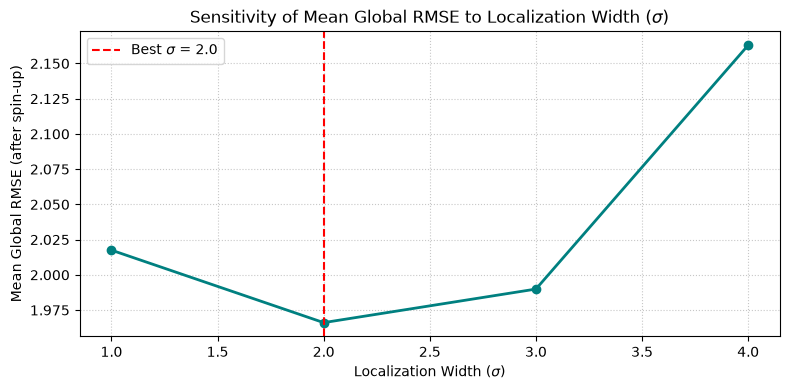

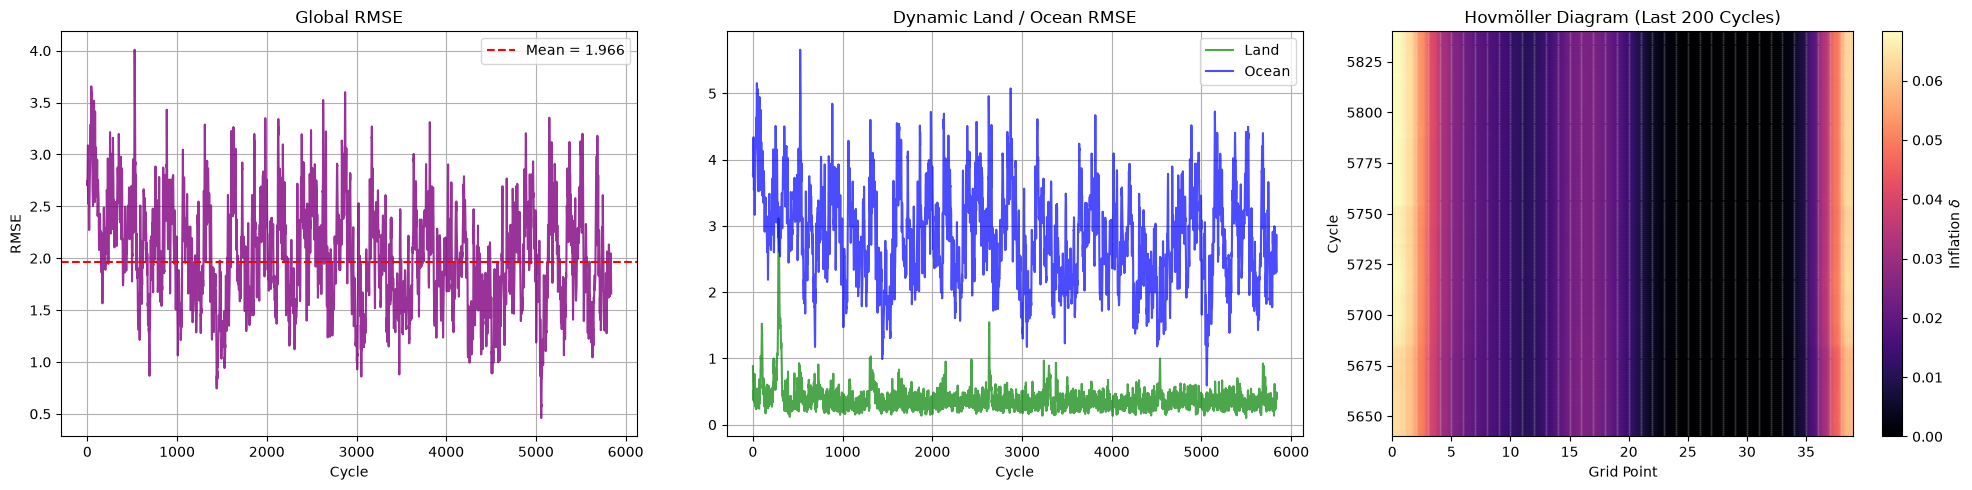

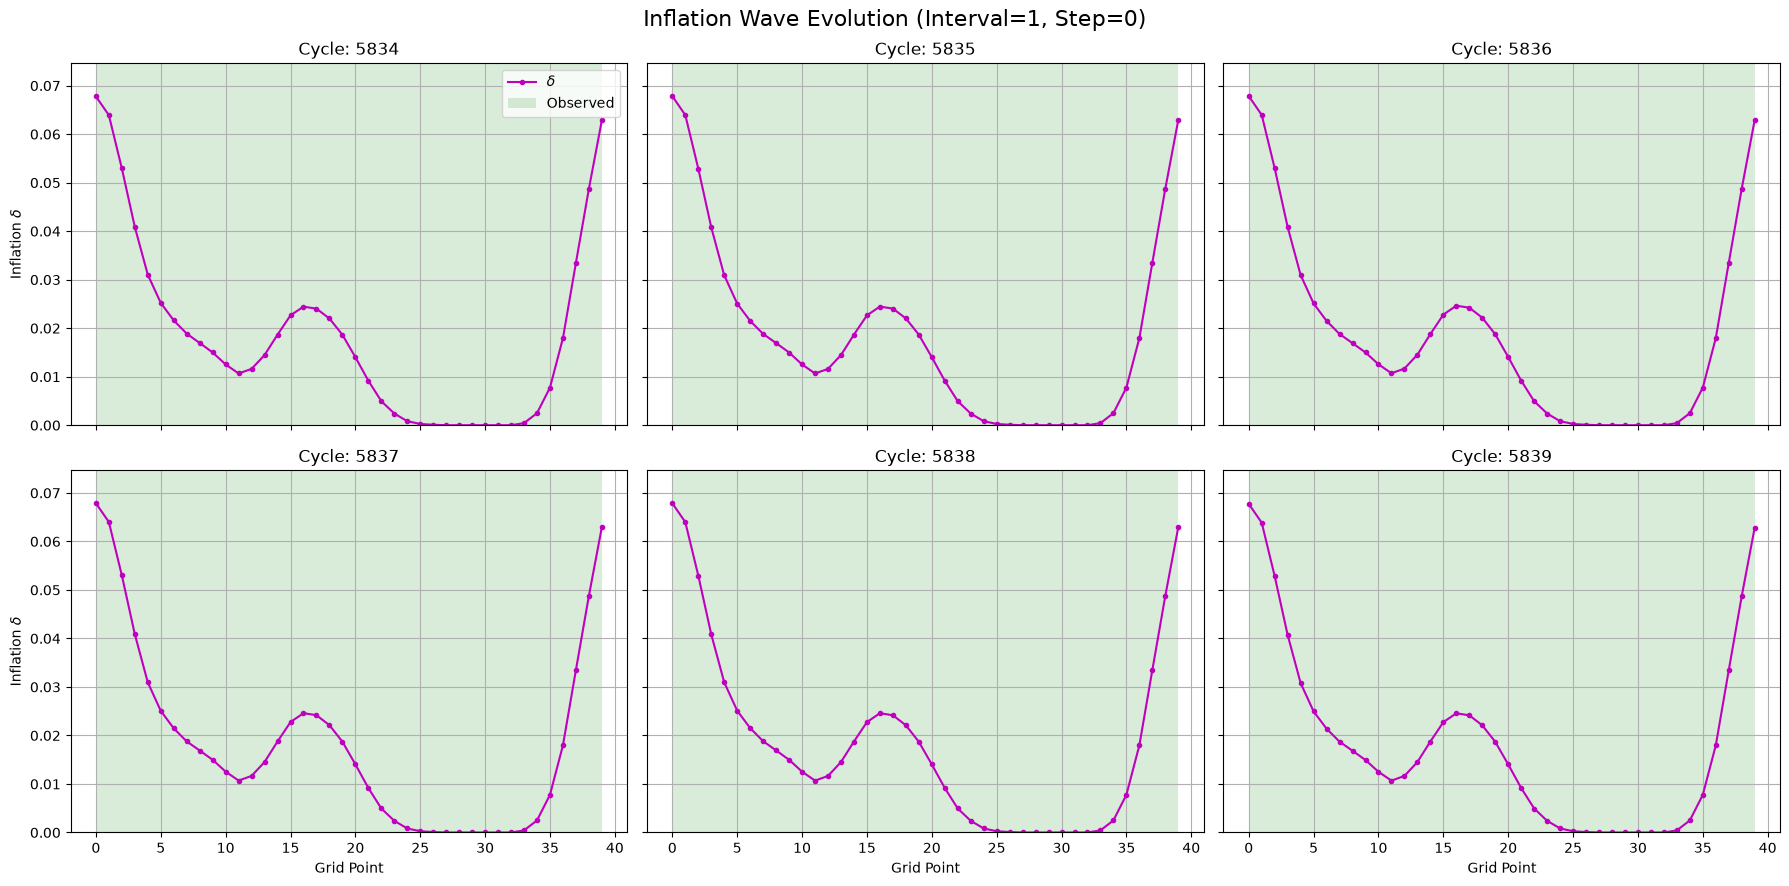

In [36]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- 安全策: 変数が欠けている場合に備えて再構築 ---
if 'obs_indices_history' not in locals():
    print("obs_indices_history を再構築中...")
    obs_indices_history = []
    for shift in range(N):
        idx = (np.arange(0, CONFIG['swath_size']) + shift) % N
        obs_indices_history.append(idx)

# 地球を1周するのに必要なサイクル数
full_rotation_cycles = (N * CONFIG['move_interval']) // math.gcd(N, CONFIG['move_step'])

# =====================================================================
# 4. 可視化
# =====================================================================
ex_c = int(num_cycles * 0.2)

# -------------------------------------------------------------------
# [追加] 0. Sigma と RMSE の感度分析プロット
# -------------------------------------------------------------------
if 'sigma_rmse_list' in locals() and len(sigma_rmse_list) > 0:
    sigmas = [item[0] for item in sigma_rmse_list]
    rmses = [item[1] for item in sigma_rmse_list]
    
    plt.figure(figsize=(8, 4))
    plt.plot(sigmas, rmses, marker='o', linestyle='-', color='teal', linewidth=2)
    plt.axvline(CONFIG['sigma'], color='red', linestyle='--', label=f'Best $\sigma$ = {CONFIG["sigma"]:.1f}')
    plt.title('Sensitivity of Mean Global RMSE to Localization Width ($\sigma$)', fontsize=12)
    plt.xlabel('Localization Width ($\sigma$)')
    plt.ylabel('Mean Global RMSE (after spin-up)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# 1. 時系列 & ホフミュラー図
# -------------------------------------------------------------------
fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))

# (A) Global RMSE
axes1[0].plot(rmse_G, color='purple', alpha=0.8, linewidth=1.5)
axes1[0].axhline(np.mean(rmse_G[ex_c:]), color='red', linestyle='--', label=f'Mean = {np.mean(rmse_G[ex_c:]):.3f}')
axes1[0].set_title('Global RMSE')
axes1[0].set_xlabel('Cycle'); axes1[0].set_ylabel('RMSE')
axes1[0].legend(); axes1[0].grid(True)

# (B) Dynamic Land & Ocean RMSE
axes1[1].plot(rmse_L, color='green', alpha=0.7, label=f'Land')
axes1[1].plot(rmse_O, color='blue', alpha=0.7, label=f'Ocean')
axes1[1].set_title('Dynamic Land / Ocean RMSE')
axes1[1].set_xlabel('Cycle')
axes1[1].legend(); axes1[1].grid(True)

# (C) ホフミュラー図 (直近200サイクル固定にすることで動きを見えやすくする)
plot_cycles = 200
start_c = max(0, num_cycles - plot_cycles)
c_im = axes1[2].imshow(delta_hist[start_c:, :], aspect='auto', cmap='magma', origin='lower',
                       extent=[0, N-1, start_c, num_cycles])
for t in range(start_c, num_cycles):
    shift = ((t // CONFIG['move_interval']) * CONFIG['move_step']) % N
    axes1[2].plot(obs_indices_history[shift], np.full_like(obs_indices_history[shift], t), 'w.', markersize=1, alpha=0.2)
axes1[2].set_title('Hovmöller Diagram (Last 200 Cycles)')
axes1[2].set_xlabel('Grid Point'); axes1[2].set_ylabel('Cycle')
fig1.colorbar(c_im, ax=axes1[2], label='Inflation $\delta$')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2. スナップショット6枚 (波の伝播)
# -------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
axes2 = axes2.flatten()

# 【修正】周期が短すぎる場合（今回のStep=30など）は、直近の6サイクルを連続でコマ送りする。
# そうでない場合は、1周分を綺麗に6分割する。
if full_rotation_cycles < 6:
    snapshot_cycles = np.arange(num_cycles - 6, num_cycles)
else:
    start_snapshot_range = max(0, num_cycles - full_rotation_cycles)
    snapshot_cycles = np.linspace(start_snapshot_range, num_cycles - 1, 6, dtype=int)

# 表示範囲の動的計算
start_for_max = min(snapshot_cycles)
max_delta = np.max(delta_hist[start_for_max:, :]) * 1.1

for i, ax in enumerate(axes2):
    c = snapshot_cycles[i]
    delta_snapshot = delta_hist[c, :]
    
    # その時点のシフト量を計算
    shift = ((c // CONFIG['move_interval']) * CONFIG['move_step']) % N
    obs_idx = obs_indices_history[shift]
    
    ax.plot(delta_snapshot, 'm-o', markersize=3, linewidth=1.5, label='$\delta$')
    ax.fill_between(np.arange(N), 0, max_delta, where=np.isin(np.arange(N), obs_idx), 
                    facecolor='green', alpha=0.15, label='Observed')
    
    ax.set_title(f'Cycle: {c}')
    ax.set_ylim(0, max_delta) 
    ax.grid(True)
    
    if i >= 3: ax.set_xlabel('Grid Point')
    if i % 3 == 0: ax.set_ylabel('Inflation $\delta$')
    if i == 0: ax.legend(loc='upper right')

plt.suptitle(f'Inflation Wave Evolution (Interval={CONFIG["move_interval"]}, Step={CONFIG["move_step"]})', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [37]:
# =====================================================================
        # 比較用関数：固定インフレーション版LETKF (デルタ更新なし)
        # =====================================================================
def run_LETKF_Fixed_Moving_Logic(delta, sigma):
    # 適応LETKFと同じロジックだが、delta_arrayを更新せずに計算
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw = np.full(N, F)
    x_raw[min(19, N-1)] += 0.001
    X_a = M(x_raw[:, None] + init_noise, dt, steps_spin_up)
    
    # ここでdeltaを更新せずに固定
    delta_array = np.full(N, delta) 
    
    record_rmse_global = np.zeros(num_cycles)
    record_rmse_land = np.zeros(num_cycles)
    record_rmse_ocean = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        shift = ((t // CONFIG["move_interval"]) * CONFIG["move_step"]) % N
        curr_obs_indices = obs_indices_history[shift]
        curr_unobs_indices = np.setdiff1d(np.arange(N), curr_obs_indices)
        obs_size = len(curr_obs_indices)
        
        H_mat = H_mats[shift]
        W_weights = W_list_final[shift]
        R_diag = np.ones(obs_size)
        y_o = np.asarray(y_o_data_full[t, curr_obs_indices]).ravel()
        
        X_b = M(X_a, dt, sampling_interval)
        # ループ内の発散チェックをこれに差し替えてください
        if not np.all(np.isfinite(X_b)): 
            record_rmse_global[:] = float('inf')
            return record_rmse_global, record_rmse_land, record_rmse_ocean, None
            
        x_b_mean = np.mean(X_b, axis=1)
        inflation_factor = np.sqrt(1.0 + delta_array) / np.sqrt(m - 1.0)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor[:, None]
        Y_b = H_mat @ Z_b
        # サイズを合わせたい
        innovation = np.asarray(y_o - (H_mat @ x_b_mean)).ravel()
        
        X_a = np.zeros((N, m))
        for i in range(N):
            w_i = W_weights[i, :]
            R_loc_inv_diag = np.diag(w_i / R_diag)
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag @ Y_b)
            D, C = np.linalg.eigh(P_a_tilde_inv)
            P_a_tilde = C @ np.diag(1.0 / D) @ C.T
            W_mat = C @ np.diag(1.0 / np.sqrt(D)) @ C.T
            w_vec = P_a_tilde @ Y_b.T @ R_loc_inv_diag @ innovation
            T_mat = w_vec[:, None] + np.sqrt(m - 1.0) * W_mat
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T_mat
            
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse_global[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        record_rmse_land[t] = np.sqrt(np.mean((x_a_mean[curr_obs_indices] - true_states[t, curr_obs_indices])**2))
        record_rmse_ocean[t] = np.sqrt(np.mean((x_a_mean[curr_unobs_indices] - true_states[t, curr_unobs_indices])**2))
            
    return record_rmse_global, record_rmse_land, record_rmse_ocean, None

# =====================================================================
        # 固定LETKFの最適デルタ探索 ＆ 時系列取得の統合フロー
        # =====================================================================

def find_best_fixed_delta(sigma):
    print("固定インフレーションの最適Deltaを探索中...")
    fixed_deltas = np.arange(0.0, 0.45, 0.05)
    best_d = 0.0
    min_rmse = float('inf')
    
    for d in fixed_deltas:
        rmse_g, _, _, _ = run_LETKF_Fixed_Moving_Logic(d, sigma)
        
        # [改善版] RMSEの計算をより堅牢に
        ex_c = int(num_cycles * 0.2)
        subset = rmse_g[ex_c:]
        
        # 1. NaNやInfが含まれていたら、その時点でRMSEを無限大にする
        if not np.all(np.isfinite(subset)):
            mean_rmse = float('inf')
        else:
            mean_rmse = np.mean(subset)
            
        print(f"Delta={d:.2f} -> Mean RMSE={mean_rmse:.4f}")
        
        if mean_rmse < min_rmse:
            min_rmse = mean_rmse
            best_d = d
            
    print(f"探索完了: 最適Fixed Delta = {best_d:.2f} (Global Mean RMSE = {min_rmse:.4f})")
    return best_d





### 最適 $\sigma$ にて静的LETKFでの最適 $\delta$ を探索

In [38]:
# 1. まず最適デルタを決定
best_fixed_delta = find_best_fixed_delta(best_sigma)

# 2. そのデルタで本番の時系列データを取得
rmse_fixed_G, rmse_fixed_L, rmse_fixed_O, _ = run_LETKF_Fixed_Moving_Logic(best_fixed_delta, best_sigma)

固定インフレーションの最適Deltaを探索中...


ValueError: operands could not be broadcast together with shapes (40,) (20,) 

## Global, Land, Oceanでの静的、動的LETKFのRMSE時間変化比較

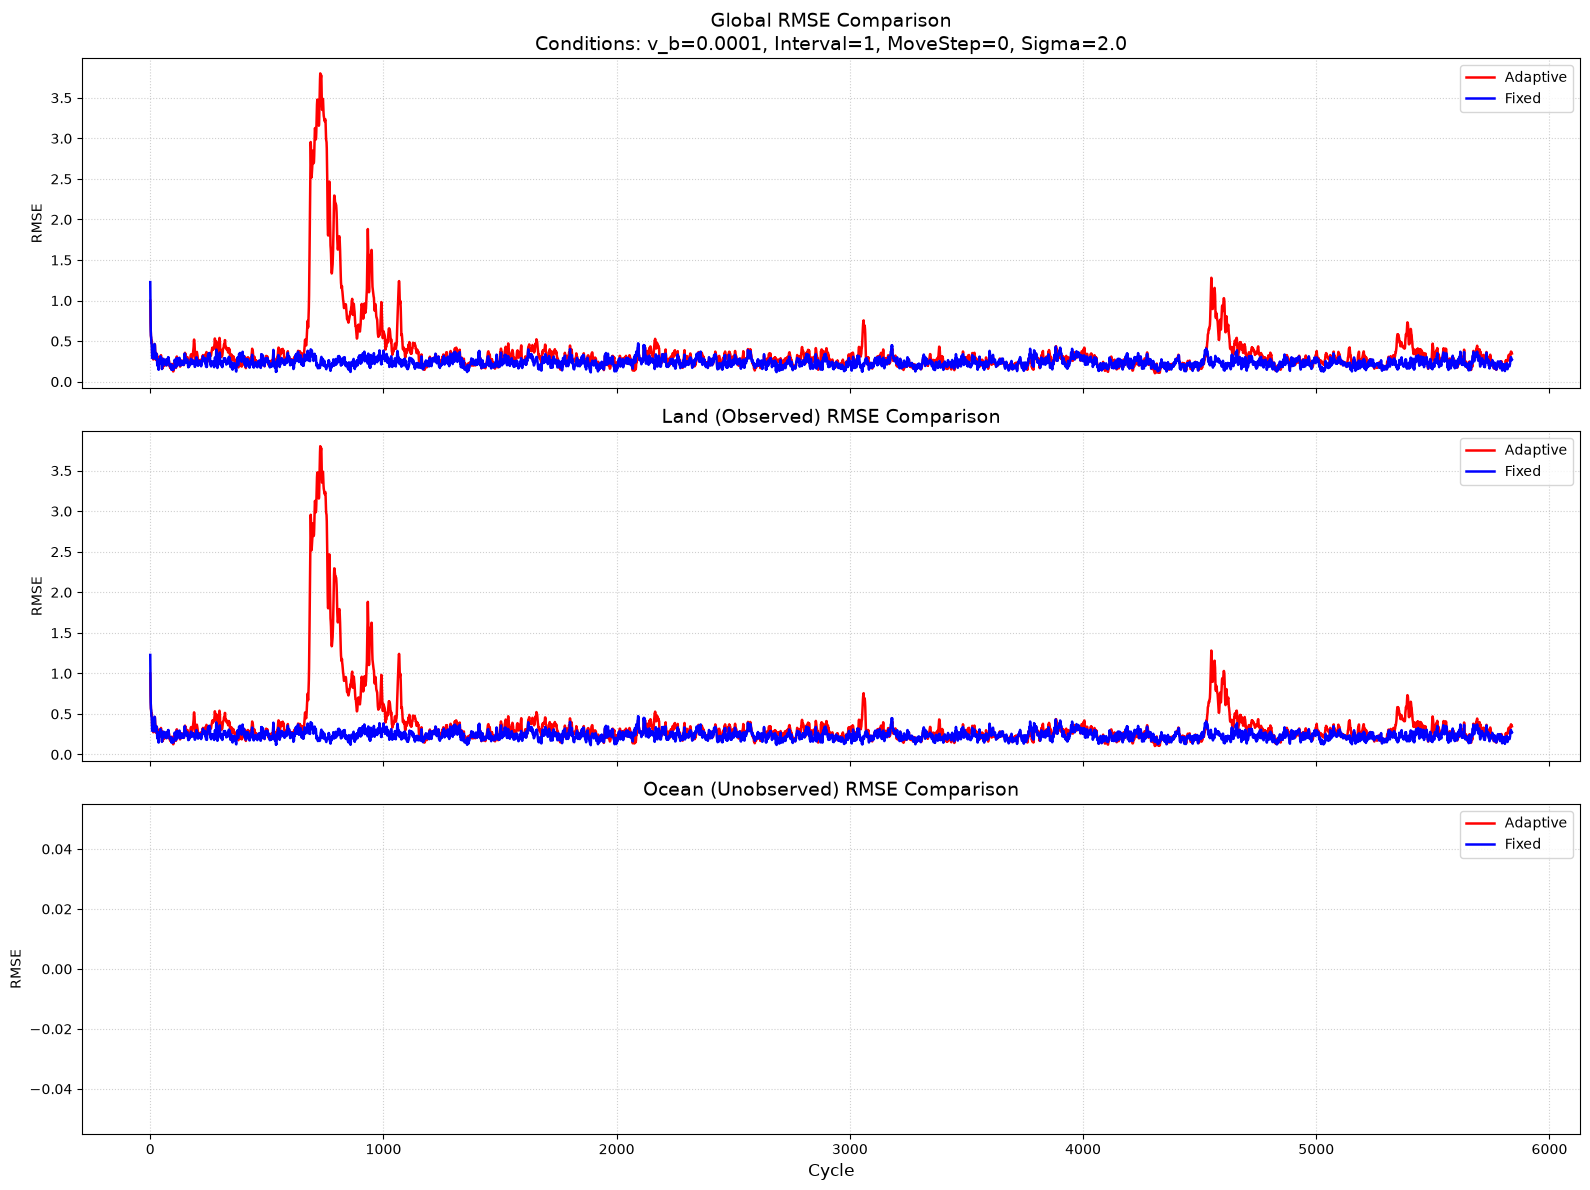

実験条件: Conditions: v_b=0.0001, Interval=1, MoveStep=0, Sigma=2.0
-----------------------------------------------------------------
Area       | Adaptive Mean   | Fixed Mean      | Improvement
-----------------------------------------------------------------
Global     | 0.2828          | 0.2331          | -21.3%
Land       | 0.2828          | 0.2331          | -21.3%
Ocean      | nan          | nan          | +nan%


In [ ]:
# =====================================================================
# 3. 比較プロット (前回のコードをそのまま実行)
# =====================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

config_str = f"Conditions: v_b={CONFIG['v_b']:.4f}, Interval={CONFIG['move_interval']}, MoveStep={CONFIG['move_step']}, Sigma={CONFIG['sigma']:.1f}"
col_ada = 'red'
col_fix = 'blue'
lw = 1.8

# (A) Global
axes[0].plot(rmse_G, color=col_ada, linestyle='-', linewidth=lw, label='Adaptive')
axes[0].plot(rmse_fixed_G, color=col_fix, linestyle='-', linewidth=lw, label='Fixed')
axes[0].set_title(f'Global RMSE Comparison\n{config_str}', fontsize=14)
axes[0].set_ylabel('RMSE')
axes[0].legend(loc='upper right'); axes[0].grid(True, linestyle=':', alpha=0.6)

# (B) Land
axes[1].plot(rmse_L, color=col_ada, linestyle='-', linewidth=lw, label='Adaptive')
axes[1].plot(rmse_fixed_L, color=col_fix, linestyle='-', linewidth=lw, label='Fixed')
axes[1].set_title('Land (Observed) RMSE Comparison', fontsize=14)
axes[1].set_ylabel('RMSE')
axes[1].legend(loc='upper right'); axes[1].grid(True, linestyle=':', alpha=0.6)

# (C) Ocean
axes[2].plot(rmse_O, color=col_ada, linestyle='-', linewidth=lw, label='Adaptive')
axes[2].plot(rmse_fixed_O, color=col_fix, linestyle='-', linewidth=lw, label='Fixed')
axes[2].set_title('Ocean (Unobserved) RMSE Comparison', fontsize=14)
axes[2].set_xlabel('Cycle', fontsize=12); axes[2].set_ylabel('RMSE')
axes[2].legend(loc='upper right'); axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 定量的比較出力
ex_c = int(num_cycles * 0.2)
print("="*65)
print(f"実験条件: {config_str}")
print("-"*65)
print(f"{'Area':<10} | {'Adaptive Mean':<15} | {'Fixed Mean':<15} | {'Improvement':<10}")
print("-"*65)
for area, ada, fix in zip(['Global', 'Land', 'Ocean'], 
                          [np.mean(rmse_G[ex_c:]), np.mean(rmse_L[ex_c:]), np.mean(rmse_O[ex_c:])],
                          [np.mean(rmse_fixed_G[ex_c:]), np.mean(rmse_fixed_L[ex_c:]), np.mean(rmse_fixed_O[ex_c:])]):
    imp = (fix - ada) / fix * 100
    print(f"{area:<10} | {ada:.4f}          | {fix:.4f}          | {imp:+.1f}%")
print("="*65)

# 1. 実行
rmse_fixed_G, rmse_fixed_L, rmse_fixed_O, _ = run_LETKF_Fixed_Moving_Logic(best_fixed_delta, best_sigma)
